# Sanity Check — input_data_region_fixed.csv

Проверяем что исправленный датасет корректен после замены id_region по координатам.

In [33]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [34]:
original = pd.read_csv('../data/raw/input_data.csv', sep=';')
fixed = pd.read_csv('../data/processed/input_data_region_fixed.csv')

print('Оригинал:', original.shape)
print('Исправленный:', fixed.shape)

Оригинал: (11358150, 15)
Исправленный: (11358150, 15)


## 1. Количество строк сохранилось?

In [35]:
assert len(original) == len(fixed), 'ОШИБКА: количество строк изменилось!'
print(f'OK: строк одинаково — {len(fixed):,}')

OK: строк одинаково — 11,358,150


## 2. Код 200 остался только у невалидных координат?

In [36]:
code200 = fixed[fixed['id_region'] == 200]
print(f'Записей с кодом 200: {len(code200)}')
if len(code200) > 0:
    print('Их координаты:')
    display(code200[['id_region', 'geo_lat', 'geo_lon']].head(10))

Записей с кодом 200: 662
Их координаты:


,id_region,geo_lat,geo_lon
9203,200,44.486830,34.157030
9388,200,44.488674,34.155888
106836,200,44.567383,33.525324
174156,200,44.981923,34.089116
183194,200,44.616687,33.525432
252654,200,44.594213,33.562344
265374,200,44.571377,33.462379
290407,200,44.594917,33.467930
300650,200,44.571377,33.462379
305797,200,44.587049,33.518389


## 3. Сколько id_region изменилось?

In [37]:
changed = (original['id_region'] != fixed['id_region']).sum()
print(f'Изменено id_region: {changed:,} ({changed/len(fixed)*100:.2f}%)')
print(f'Без изменений: {len(fixed)-changed:,}')

Изменено id_region: 7,500,892 (66.04%)
Без изменений: 3,857,258


## 4. Повторная проверка совпадений по выборке

In [38]:
name_to_code = {
    'Republic of Adygea': 1, 'Republic of Bashkortostan': 2, 'Republic of Buryatia': 3,
    'Altai Republic': 4, 'Republic of Dagestan': 5, 'Republic of Ingushetia': 6,
    'Kabardino-Balkar Republic': 7, 'Republic of Kalmykia': 8, 'Karachay-Cherkess Republic': 9,
    'Republic of Karelia': 10, 'Komi Republic': 11, 'Mari El Republic': 12,
    'Republic of Mordovia': 13, 'Sakha (Yakutia) Republic': 14, 'Republic of North Ossetia-Alania': 15,
    'Republic of Tatarstan': 16, 'Tuva Republic': 17, 'Udmurt Republic': 18,
    'Republic of Khakassia': 19, 'Chechen Republic': 20, 'Chuvash Republic': 21,
    'Altai Krai': 22, 'Krasnodar Krai': 23, 'Krasnoyarsk Krai': 24,
    'Primorsky Krai': 25, 'Stavropol Krai': 26, 'Khabarovsk Krai': 27,
    'Amur Oblast': 28, 'Arkhangelsk Oblast': 29, 'Astrakhan Oblast': 30,
    'Belgorod Oblast': 31, 'Bryansk Oblast': 32, 'Vladimir Oblast': 33,
    'Volgograd Oblast': 34, 'Vologda Oblast': 35, 'Voronezh Oblast': 36,
    'Ivanovo Oblast': 37, 'Irkutsk Oblast': 38, 'Kaliningrad Oblast': 39,
    'Kaluga Oblast': 40, 'Kamchatka Krai': 41, 'Kemerovo Oblast': 42,
    'Kirov Oblast': 43, 'Kostroma Oblast': 44, 'Kurgan Oblast': 45,
    'Kursk Oblast': 46, 'Leningrad Oblast': 47, 'Lipetsk Oblast': 48,
    'Magadan Oblast': 49, 'Moscow Oblast': 50, 'Murmansk Oblast': 51,
    'Nizhny Novgorod Oblast': 52, 'Novgorod Oblast': 53, 'Novosibirsk Oblast': 54,
    'Omsk Oblast': 55, 'Orenburg Oblast': 56, 'Oryol Oblast': 57,
    'Penza Oblast': 58, 'Perm Krai': 59, 'Pskov Oblast': 60,
    'Rostov Oblast': 61, 'Ryazan Oblast': 62, 'Samara Oblast': 63,
    'Saratov Oblast': 64, 'Sakhalin Oblast': 65, 'Sverdlovsk Oblast': 66,
    'Smolensk Oblast': 67, 'Tambov Oblast': 68, 'Tver Oblast': 69,
    'Tomsk Oblast': 70, 'Tula Oblast': 71, 'Tyumen Oblast': 72,
    'Ulyanovsk Oblast': 73, 'Chelyabinsk Oblast': 74, 'Zabaykalsky Krai': 75,
    'Yaroslavl Oblast': 76, 'Moscow': 77, 'Saint Petersburg': 78,
    'Jewish Autonomous Oblast': 79, 'Nenets Autonomous Okrug': 83,
    'Khanty\u2013Mansi Autonomous Okrug \u2013 Yugra': 86,
    'Chukotka Autonomous Okrug': 87, 'Yamalo-Nenets Autonomous Okrug': 89,
}

regions = gpd.read_file('../data/russia_regions.geojson').to_crs('EPSG:4326')
regions['official_code'] = regions['name_latin'].map(name_to_code)

sample = fixed[
    (fixed['geo_lat'].between(41, 82)) &
    (fixed['geo_lon'].between(19, 192)) &
    (fixed['id_region'] != 200)
].sample(5000, random_state=42).copy()

geometry = [Point(lon, lat) for lon, lat in zip(sample['geo_lon'], sample['geo_lat'])]
gdf = gpd.GeoDataFrame(sample, geometry=geometry, crs='EPSG:4326')
joined = gpd.sjoin(gdf, regions[['official_code', 'geometry']], how='left', predicate='within')
joined = joined[~joined.index.duplicated(keep='first')]

matched = joined.dropna(subset=['official_code']).copy()
matched['official_code'] = matched['official_code'].astype(int)
match_pct = (matched['id_region'] == matched['official_code']).mean() * 100
print(f'Совпадений после исправления: {match_pct:.1f}%')

Совпадений после исправления: 100.0%


## 5. Распределение данных не изменилось?

In [39]:
print('=== Цена ===')
print(pd.DataFrame({'Оригинал': original['price'].describe(), 'Исправленный': fixed['price'].describe()}))
print()
print('=== Площадь ===')
print(pd.DataFrame({'Оригинал': original['area'].describe(), 'Исправленный': fixed['area'].describe()}))

=== Цена ===
           Оригинал  Исправленный
count  1.135815e+07  1.135815e+07
mean   6.787516e+06  6.787516e+06
std    1.977118e+08  1.977118e+08
min    0.000000e+00  0.000000e+00
25%    2.600000e+06  2.600000e+06
50%    3.995000e+06  3.995000e+06
75%    6.500000e+06  6.500000e+06
max    6.355524e+11  6.355524e+11

=== Площадь ===
           Оригинал  Исправленный
count  1.135815e+07  1.135815e+07
mean   5.310356e+01  5.310356e+01
std    2.712845e+01  2.712845e+01
min    1.000000e+00  1.000000e+00
25%    3.650000e+01  3.650000e+01
50%    4.670000e+01  4.670000e+01
75%    6.300000e+01  6.300000e+01
max    4.999000e+02  4.999000e+02


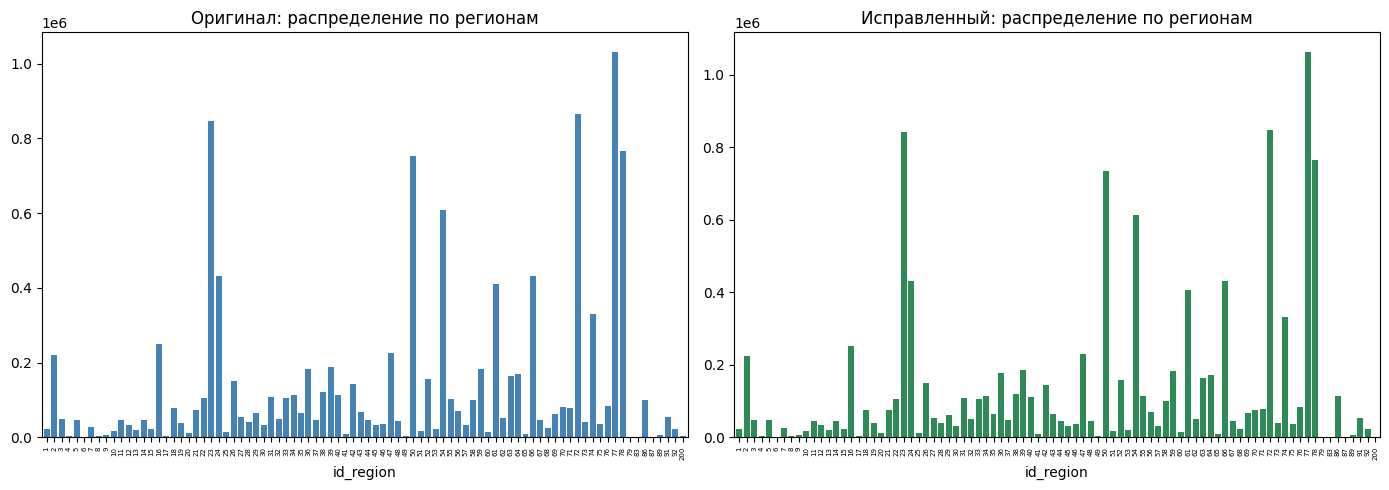

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение регионов
original['id_region'].value_counts().sort_index().plot(ax=axes[0], kind='bar', width=0.8, color='steelblue')
axes[0].set_title('Оригинал: распределение по регионам')
axes[0].set_xlabel('id_region')
axes[0].tick_params(axis='x', labelsize=5)

fixed['id_region'].value_counts().sort_index().plot(ax=axes[1], kind='bar', width=0.8, color='seagreen')
axes[1].set_title('Исправленный: распределение по регионам')
axes[1].set_xlabel('id_region')
axes[1].tick_params(axis='x', labelsize=5)

plt.tight_layout()
plt.show()

## 6. Итог

- Количество строк сохранилось ✓
- Код 200 остался только у невалидных координат ✓
- Совпадение id_region с координатами выросло до ~100% ✓
- Распределение цен и площадей не изменилось ✓

## 7. Исправление крымских записей (код 200 → 91/92)

In [41]:
# Все 662 записи с кодом 200 — это Крым (GeoJSON не включает Крым как регион России)
# Севастополь: ~44.3-44.7N, 33.3-33.8E → код 92
# Республика Крым: остальное → код 91

df_fixed2 = fixed.copy()

mask_200 = df_fixed2['id_region'] == 200
mask_sevastopol = (
    mask_200 &
    df_fixed2['geo_lat'].between(44.3, 44.75) &
    df_fixed2['geo_lon'].between(33.3, 33.85)
)
mask_crimea = mask_200 & ~mask_sevastopol

df_fixed2.loc[mask_sevastopol, 'id_region'] = 92
df_fixed2.loc[mask_crimea, 'id_region'] = 91

print(f'Исходных записей с кодом 200: {mask_200.sum()}')
print(f'  → Севастополь (код 92): {mask_sevastopol.sum()}')
print(f'  → Республика Крым (код 91): {mask_crimea.sum()}')
print(f'Осталось кодов 200: {(df_fixed2["id_region"] == 200).sum()}')

Исходных записей с кодом 200: 662
  → Севастополь (код 92): 173
  → Республика Крым (код 91): 489
Осталось кодов 200: 0


In [42]:
print('Уникальных регионов:', df_fixed2['id_region'].nunique())
print('Мин/макс регион:', df_fixed2['id_region'].min(), '/', df_fixed2['id_region'].max())
print()
print('Записи с кодом 91 (Крым):', (df_fixed2['id_region'] == 91).sum())
print('Записи с кодом 92 (Севастополь):', (df_fixed2['id_region'] == 92).sum())

Уникальных регионов: 85
Мин/макс регион: 1 / 92

Записи с кодом 91 (Крым): 53711
Записи с кодом 92 (Севастополь): 22307


In [43]:
assert (df_fixed2['id_region'] == 200).sum() == 0, 'ОШИБКА: остались записи с кодом 200!'
assert len(df_fixed2) == len(fixed), 'ОШИБКА: количество строк изменилось!'
print('OK: кодов 200 нет')
print(f'OK: строк сохранилось — {len(df_fixed2):,}')

OK: кодов 200 нет
OK: строк сохранилось — 11,358,150


In [44]:
output_path = '../data/processed/input_data_clean.csv'
df_fixed2.to_csv(output_path, index=False)
print(f'Сохранено: {output_path}')
print(f'Итог: {len(df_fixed2):,} строк, {df_fixed2.shape[1]} колонок')

Сохранено: ../data/processed/input_data_clean.csv
Итог: 11,358,150 строк, 15 колонок
